# Image Dataset Pipeline Notebook
Notebook lengkap untuk data wrangling, cleaning, EDA, visualisasi, balancing check, preprocessing, dan export dataset gambar siap training AI.

## Pertanyaan Bisnis

Jenis masalah kerusakan kulit apa yang paling dominan pada dataset citra kulit dan tingkat keparahannya berdasarkan hasil analisis dataset untuk mendukung analisis kesehatan kulit selama periode pengembangan project?

## 1. Import Library

In [1]:

import os
import shutil
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use('default')

print("Library berhasil diimport")


Library berhasil diimport


## 2. Tentukan Path Dataset

In [2]:

# Ganti sesuai lokasi dataset kamu
DATASET_PATH = r"D:/Analisis data cptn/Data capston project"

# Folder output clean dataset
OUTPUT_PATH = "clean_dataset"

DATASET_PATH


'D:/Analisis data cptn/Data capston project'

## 3. Membaca Dataset Gambar Otomatis

In [3]:

data = []
DATASET_PATH = "Data capston project"
valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')

for severity in os.listdir(DATASET_PATH): 

    severity_path = os.path.join(DATASET_PATH, severity)

    if os.path.isdir(severity_path):

        for disease in os.listdir(severity_path):

            disease_path = os.path.join(severity_path, disease)

            if os.path.isdir(disease_path):

                for file in os.listdir(disease_path):

                    if file.lower().endswith(valid_extensions):

                        filepath = os.path.join(disease_path, file)

                        try:
                            with Image.open(filepath) as img:

                                width, height = img.size

                                data.append({
                                    'severity': severity,
                                    'disease': disease,
                                    'filename': file,
                                    'filepath': filepath,
                                    'width': width,
                                    'height': height,
                                    'format': img.format,
                                    'mode': img.mode
                                })

                        except:
                            print(f"Corrupt image: {filepath}")

df = pd.DataFrame(data)

print("Total gambar:", len(df))
df.head()


Total gambar: 14098


,severity,disease,filename,filepath,width,height,format,mode
0,Normal,healthy skin,17053005206957139408735922636266 - Gabriel Mar...,Data capston project\Normal\healthy skin\17053...,4080,2296,JPEG,RGB
1,Normal,healthy skin,17053016125375393346221463682922 - Billy Endry...,Data capston project\Normal\healthy skin\17053...,3000,4000,JPEG,RGB
2,Normal,healthy skin,20240115_115549.jpg,Data capston project\Normal\healthy skin\20240...,4000,3000,JPEG,RGB
3,Normal,healthy skin,20240115_115615.jpg,Data capston project\Normal\healthy skin\20240...,4000,3000,JPEG,RGB
4,Normal,healthy skin,20240115_120344.jpg,Data capston project\Normal\healthy skin\20240...,4000,3000,JPEG,RGB


## 4. Simpan Metadata Dataset

In [4]:

df.to_csv("metadata_raw_dataset.csv", index=False)

print("metadata_raw_dataset.csv berhasil dibuat")


metadata_raw_dataset.csv berhasil dibuat


## 5. Data Cleaning

### Cek Missing Values

In [5]:

df.isnull().sum()


severity    0
disease     0
filename    0
filepath    0
width       0
height      0
format      0
mode        0
dtype: int64

### Cek Duplicate Filepath

In [6]:

duplicate_count = df.duplicated(subset=['filepath']).sum()

print("Jumlah duplicate:", duplicate_count)


Jumlah duplicate: 0


### Hapus Duplicate

In [7]:

df = df.drop_duplicates(subset=['filepath'])

print("Dataset setelah remove duplicate:", len(df))


Dataset setelah remove duplicate: 14098


### Cek Ukuran Gambar

In [8]:

df[['width','height']].describe()


,width,height
count,14098.000000,14098.000000
mean,687.582636,636.940914
std,291.544372,320.710956
min,194.000000,122.000000
25%,512.000000,472.000000
50%,600.000000,512.000000
75%,1024.000000,1024.000000
max,4160.000000,4608.000000


### Visualisasi Resolusi

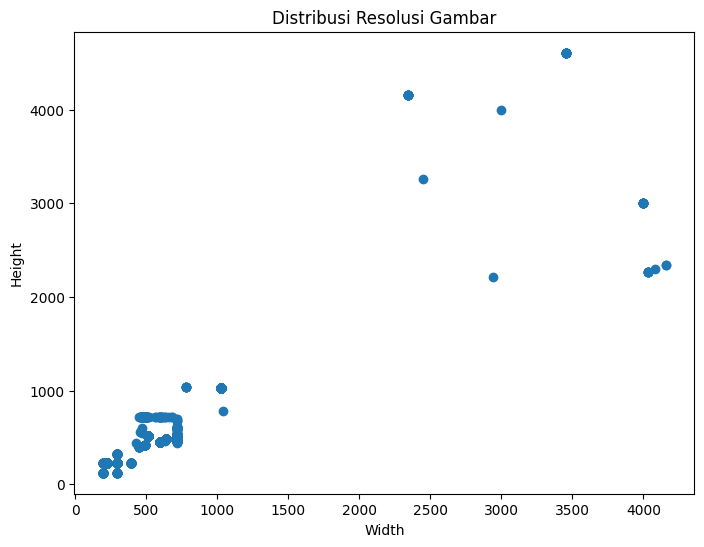

In [9]:

plt.figure(figsize=(8,6))

plt.scatter(df['width'], df['height'])

plt.xlabel("Width")
plt.ylabel("Height")

plt.title("Distribusi Resolusi Gambar")

plt.show()


### Resize dan Convert RGB

In [10]:

TARGET_SIZE = (224, 224)

cleaned_data = []

for idx, row in df.iterrows():

    try:
        img = Image.open(row['filepath'])

        img = img.convert("RGB")

        img = img.resize(TARGET_SIZE)

        cleaned_data.append({
            'severity': row['severity'],
            'disease': row['disease'],
            'filename': row['filename'],
            'image': img
        })

    except:
        print("Failed:", row['filepath'])

print("Total cleaned images:", len(cleaned_data))


Total cleaned images: 14098


## 6. Exploratory Data Analysis (EDA)

### Distribusi Severity

In [11]:

severity_dist = df['severity'].value_counts()

severity_dist


severity
Terparah    8307
Ringan      2894
Sedang      2025
Normal       872
Name: count, dtype: int64

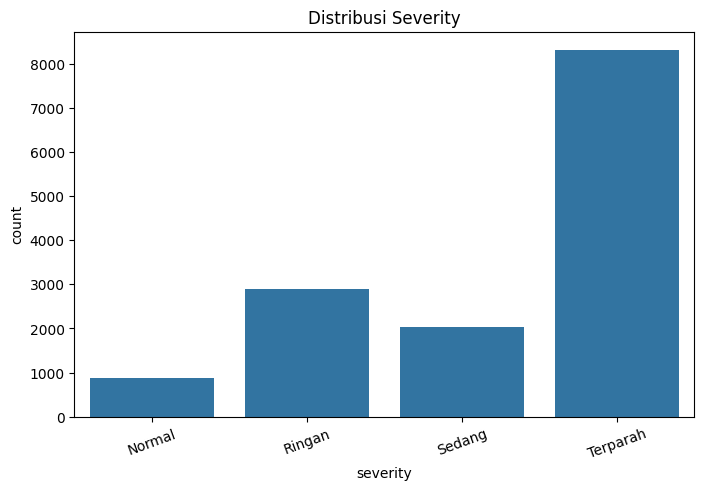

In [12]:

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='severity')

plt.title("Distribusi Severity")

plt.xticks(rotation=20)

plt.show()


### Distribusi Disease

In [13]:

disease_dist = df['disease'].value_counts()

disease_dist.head(10)


disease
Basal Cell Carcinoma (BCC)                               3323
Melanoma                                                 3140
Benign Keratosis-like Lesions (BKL)                      2079
Seborrheic Keratoses and other Benign Tumors             1844
Psoriasis pictures Lichen Planus and related diseases    1178
healthy skin                                              872
Melasma                                                   732
hyperpigmentation                                         700
Solar Lentigo                                             115
Sunburn                                                   115
Name: count, dtype: int64

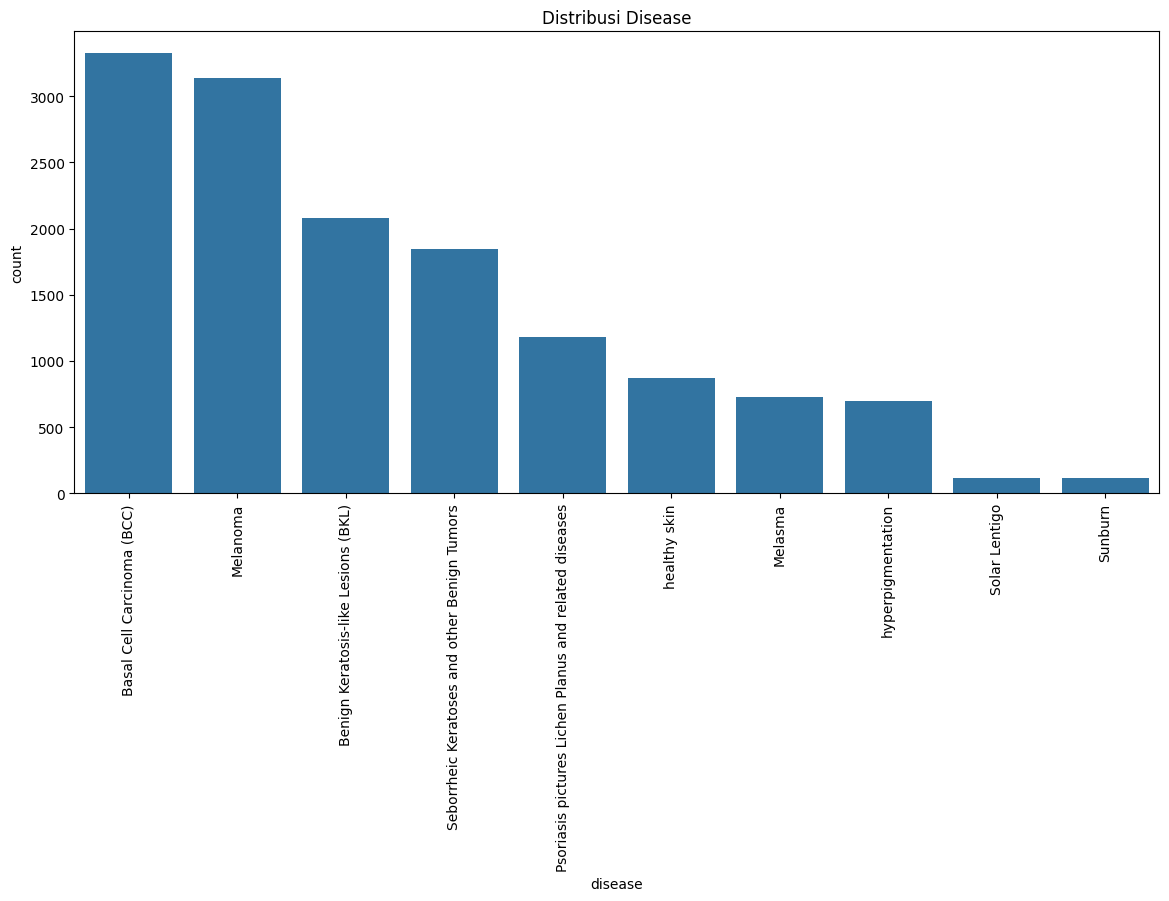

In [14]:

plt.figure(figsize=(14,6))

sns.countplot(data=df, x='disease',
              order=df['disease'].value_counts().index)

plt.xticks(rotation=90)

plt.title("Distribusi Disease")

plt.show()


### Analisis Imbalance Dataset

In [15]:

max_class = severity_dist.max()
min_class = severity_dist.min()

imbalance_ratio = round(max_class / min_class, 2)

print("Imbalance ratio:", imbalance_ratio, "x")

if imbalance_ratio <= 3:
    print("Dataset relatif seimbang")

elif imbalance_ratio <= 10:
    print("Dataset mulai imbalance")
    print("Disarankan augmentation dan class weighting")

else:
    print("Dataset sangat imbalance")
    print("Disarankan augmentation tambahan")


Imbalance ratio: 9.53 x
Dataset mulai imbalance
Disarankan augmentation dan class weighting


## 7. Visualisasi Sample Gambar

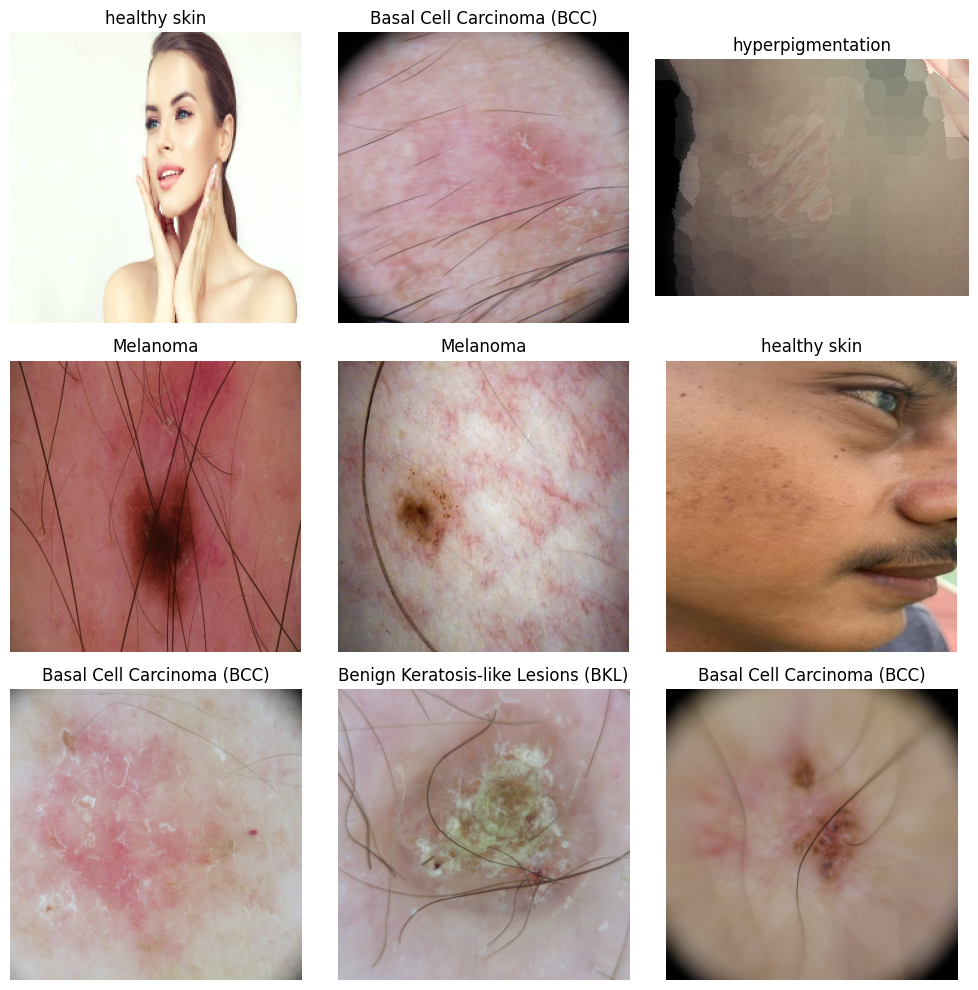

In [16]:

sample_df = df.sample(9)

fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):

    img = Image.open(row['filepath'])

    ax.imshow(img)

    ax.set_title(row['disease'])

    ax.axis('off')

plt.tight_layout()

plt.show()


## 8. Split Train Validation Test

In [17]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['severity'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['severity'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 9868
Validation: 2115
Test: 2115


## 9. Membuat Folder Clean Dataset

In [18]:

for split_name in ['train', 'val', 'test']:

    for severity in df['severity'].unique():

        folder_path = os.path.join(
            OUTPUT_PATH,
            split_name,
            severity
        )

        os.makedirs(folder_path, exist_ok=True)

print("Folder clean dataset berhasil dibuat")


Folder clean dataset berhasil dibuat


## 10. Export Gambar ke Clean Dataset

In [19]:
OUTPUT_PATH = r"D:/Analisis data cptn/clean_data"

def export_images(dataframe, split_name):

    for idx, row in dataframe.iterrows():

        try:

            # Skip jika disease kosong
            if pd.isna(row['disease']) or str(row['disease']).strip() == "":
                print("Disease kosong:", row['filepath'])
                continue

            img = Image.open(row['filepath'])

            img = img.convert("RGB")

            img = img.resize((224,224))

            # Folder penyakit
            disease_folder = str(row['disease']).strip()

            save_path = os.path.join(
                OUTPUT_PATH,
                split_name,
                str(row['severity']).strip(),
                disease_folder,
                row['filename']
            )

            # Buat folder otomatis
            os.makedirs(
                os.path.dirname(save_path),
                exist_ok=True
            )

            # Save image
            img.save(save_path)

            print("Saved:", save_path)

        except Exception as e:

            print("Failed export:", row['filepath'])
            print(e)

# Export
export_images(train_df, 'train')
export_images(val_df, 'val')
export_images(test_df, 'test')

print("Export dataset selesai")

Saved: D:/Analisis data cptn/clean_data\train\Terparah\Melanoma\ISIC_7076710.jpg
Saved: D:/Analisis data cptn/clean_data\train\Terparah\Melanoma\ISIC_7188330.jpg
Saved: D:/Analisis data cptn/clean_data\train\Ringan\Benign Keratosis-like Lesions (BKL)\ISIC_0027041.jpg
Saved: D:/Analisis data cptn/clean_data\train\Ringan\Benign Keratosis-like Lesions (BKL)\ISIC_0027239.jpg
Saved: D:/Analisis data cptn/clean_data\train\Terparah\Seborrheic Keratoses and other Benign Tumors\177_1_22.jpg
Saved: D:/Analisis data cptn/clean_data\train\Terparah\Seborrheic Keratoses and other Benign Tumors\t-leiomyomata-10.jpg
Saved: D:/Analisis data cptn/clean_data\train\Terparah\Melanoma\ISIC_7452152.jpg
Saved: D:/Analisis data cptn/clean_data\train\Terparah\Melanoma\ISIC_7534592.jpg
Saved: D:/Analisis data cptn/clean_data\train\Terparah\Basal Cell Carcinoma (BCC)\ISIC_0064470.jpg
Saved: D:/Analisis data cptn/clean_data\train\Sedang\Psoriasis pictures Lichen Planus and related diseases\t-Psoriasis-Hand-38.jpg


KeyboardInterrupt: 

## 11. Export Metadata Final

In [ ]:
OUTPUT_PATH = r"D:/Analisis data cptn/clean_data"

os.makedirs(OUTPUT_PATH, exist_ok=True)

train_df.to_csv(
    os.path.join(OUTPUT_PATH, "train_metadata.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(OUTPUT_PATH, "val_metadata.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(OUTPUT_PATH, "test_metadata.csv"),
    index=False
)

print("Metadata final berhasil disimpan")


Metadata final berhasil disimpan


## 12. Final Check

In [ ]:

print("Jumlah train :", len(train_df))
print("Jumlah val   :", len(val_df))
print("Jumlah test  :", len(test_df))



Jumlah train : 9868
Jumlah val   : 2115
Jumlah test  : 2115


## INSIGHT

1. Data yang digunakan dalam project ini adalah data gambar yang terbagi dalam 4 kategori keparahan yaitu normal, ringan, sedang, dan terparah
2. Total gambar di dataset Data capston project: 18.320.
3. Kategori severity:
    Terparah    8307
    Ringan      2894
    Sedang      2025
    Normal       872
4. Dataset sangat tidak seimbang dimana kategori terparah mendominasi (~45% dari total) sedangkan kategori normal sangat sedikit (<5% dari total)
5. Dalam setiap kategori keparahan terdapat jenis masalah kerusakan kulit yaitu 
    Normal: kulit sehat = 872
    Ringan: hyperpigmentation = 700
            Eczema = 871   
            Solar Lentigo = 115
    Sedang: Melasma = 734
            Sunburn = 117
            Psoriasis = 1178
    Terparah: Basal Cell Carcinoma (BCC) = 3323
              Melanoma = 3140
              Seborrheic Keratoses and other Benign Tumors = 1844
6. Dapat dilihat bahwa masalah kerusakan kulit paling banyak pada dataset yaitu Basal Cell Carcinoma sebanyak 3323
7. Distribusi severity menunjukkan adanya bias ke kelas parah, sehingga model rawan mengutamakan kategori terparah dan kurang sensitif terhadap kategori normal
8. Rekomendasi: 
    * augmentasi untuk kelas minoritas (Normal, Ringan)
    * class weighting saat training
    * teknik sampling yang seimbang (oversampling/undersampling)
    * Pastikan validasi dan test tetap menggunakan stratified split supaya setiap severity terwakili